### Model Implementation, Testing and Compression

#### logistic regression for multilinearity and random forest

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/financial_health_risk_dataset.csv")

In [ ]:
df.columns

Index(['user_id', 'age', 'employment_type', 'monthly_income',
       'monthly_expenses', 'monthly_savings', 'education_loan',
       'personal_loan', 'home_loan', 'vehicle_loan', 'credit_card_due',
       'total_loans', 'investment_stocks', 'investment_crypto',
       'investment_commodities', 'investment_bonds', 'credit_score',
       'emergency_fund_months', 'debt_to_income_ratio',
       'financial_health_score', 'risk_category'],
      dtype='object')

In [ ]:
data = df.drop(columns=['debt_to_income_ratio',
 'monthly_savings','total_loans','user_id','employment_type','risk_category'])

In [ ]:
df.columns

Index(['user_id', 'age', 'employment_type', 'monthly_income',
       'monthly_expenses', 'monthly_savings', 'education_loan',
       'personal_loan', 'home_loan', 'vehicle_loan', 'credit_card_due',
       'total_loans', 'investment_stocks', 'investment_crypto',
       'investment_commodities', 'investment_bonds', 'credit_score',
       'emergency_fund_months', 'debt_to_income_ratio',
       'financial_health_score', 'risk_category'],
      dtype='object')

In [ ]:
data.columns

Index(['age', 'monthly_income', 'monthly_expenses', 'education_loan',
       'personal_loan', 'home_loan', 'vehicle_loan', 'credit_card_due',
       'investment_stocks', 'investment_crypto', 'investment_commodities',
       'investment_bonds', 'credit_score', 'emergency_fund_months',
       'financial_health_score'],
      dtype='object')

In [ ]:
print(data['financial_health_score'].value_counts())

financial_health_score
48.0    249
43.0    245
49.0    245
50.0    242
44.0    239
46.0    229
47.0    226
45.0    224
52.0    213
51.0    213
42.0    210
40.0    200
53.0    196
41.0    194
55.0    187
39.0    173
38.0    163
54.0    158
56.0    149
37.0    148
57.0    147
58.0    140
35.0    127
60.0    125
59.0    122
36.0    122
34.0    101
33.0    101
61.0     94
63.0     93
32.0     83
62.0     82
31.0     67
30.0     64
65.0     57
64.0     56
29.0     47
28.0     40
67.0     39
66.0     35
27.0     27
68.0     23
69.0     21
26.0     17
25.0     17
24.0     11
70.0     10
23.0      9
71.0      5
72.0      4
74.0      3
21.0      3
22.0      2
20.0      1
75.0      1
73.0      1
Name: count, dtype: int64


In [ ]:
# Convert numeric score into 3 classes:

In [ ]:
def categorize(score):
    if score >= 55:
        return "High"
    elif score >= 40:
        return "Medium"
    else:
        return "Low"

data['financial_health_category'] = data['financial_health_score'].apply(categorize)


In [ ]:
data['financial_health_category'].value_counts()


,count
financial_health_category,
Medium,3283
High,1394
Low,1323


#### Logistic Regression (multilinearity)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(data['financial_health_category'])

X = data.drop(['financial_health_score','financial_health_category'], axis=1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, multi_class='multinomial')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
X = data.drop(['financial_health_score'], axis=1)
y = data['financial_health_category']


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)


In [ ]:
X = X.select_dtypes(include=['int64', 'float64'])


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)  # increase iterations
lr.fit(X_train, y_train)


LogisticRegression(max_iter=5000)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


Accuracy: 0.5441666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.20      0.01      0.03       279
           1       0.67      0.04      0.07       265
           2       0.55      0.97      0.70       656

    accuracy                           0.54      1200
   macro avg       0.47      0.34      0.27      1200
weighted avg       0.49      0.54      0.41      1200


Confusion Matrix:
 [[  4   0 275]
 [  4  10 251]
 [ 12   5 639]]


#### Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


RF Accuracy: 0.8091666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.87      0.81       279
           1       0.76      0.85      0.80       265
           2       0.87      0.77      0.81       656

    accuracy                           0.81      1200
   macro avg       0.79      0.83      0.81      1200
weighted avg       0.82      0.81      0.81      1200



In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X_scaled, y, cv=5)
print("Mean CV Accuracy:", cv_scores.mean())


Mean CV Accuracy: 0.7916666666666666


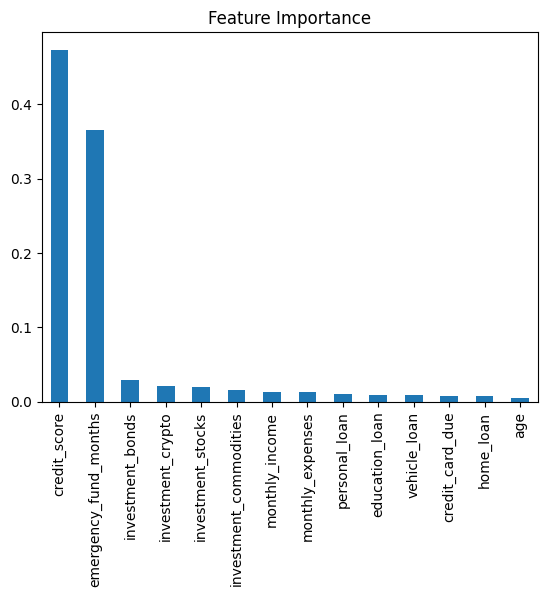

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance")
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.8058333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.87      0.81       279
           1       0.76      0.85      0.80       265
           2       0.87      0.77      0.81       656

    accuracy                           0.81      1200
   macro avg       0.79      0.83      0.81      1200
weighted avg       0.82      0.81      0.81      1200



#### Support Vector Mechnisim model

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model = SVC(kernel='rbf', C=1, gamma='scale')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.8575

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.87      0.81       279
           1       0.76      0.85      0.80       265
           2       0.87      0.77      0.81       656

    accuracy                           0.81      1200
   macro avg       0.79      0.83      0.81      1200
weighted avg       0.82      0.81      0.81      1200



#### K-Neighbors Classification

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.7733333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.87      0.81       279
           1       0.76      0.85      0.80       265
           2       0.87      0.77      0.81       656

    accuracy                           0.81      1200
   macro avg       0.79      0.83      0.81      1200
weighted avg       0.82      0.81      0.81      1200



#### XG Boost Classifier

In [ ]:
pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.8683333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.87      0.81       279
           1       0.76      0.85      0.80       265
           2       0.87      0.77      0.81       656

    accuracy                           0.81      1200
   macro avg       0.79      0.83      0.81      1200
weighted avg       0.82      0.81      0.81      1200



In [ ]:
pip install shap

In [ ]:
import shap
import matplotlib.pyplot as plt

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier()
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

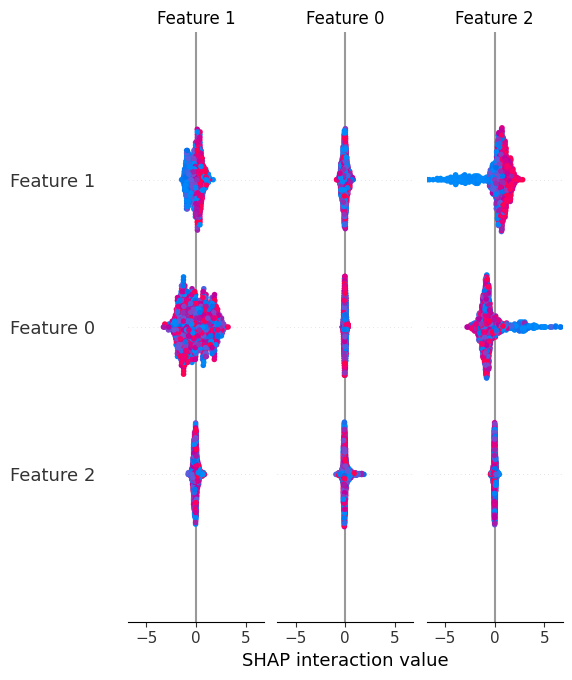

In [ ]:
shap.summary_plot(shap_values, X_test)

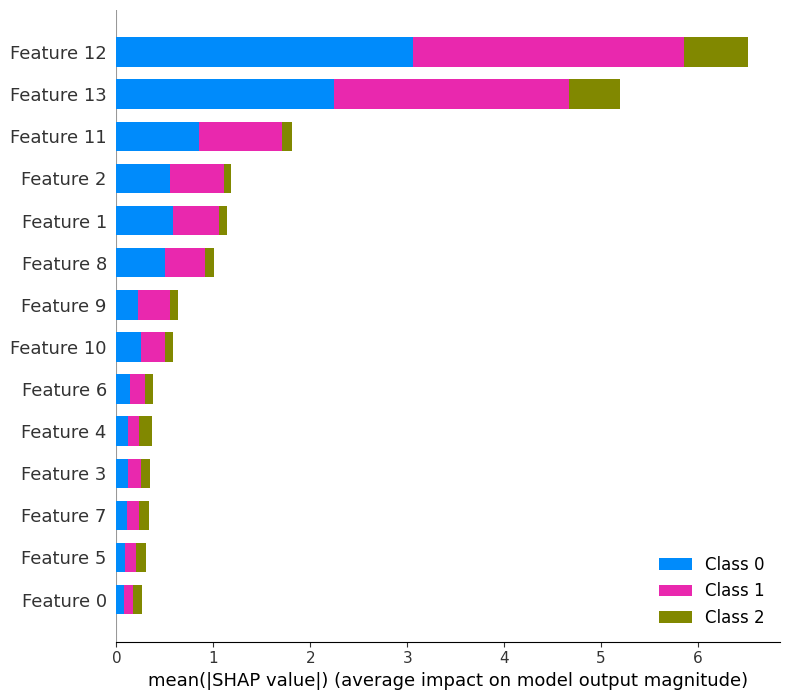

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [ ]:
import pickle

# Save model
with open("financial_risk_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model saved successfully")

Model saved successfully


In [ ]:
%%writefile app.py
import os
import streamlit as st
import numpy as np
import pickle
import plotly.graph_objects as go
import plotly.express as px

# ---------------- PAGE CONFIG ----------------
st.set_page_config(page_title="Financial AI", layout="wide")

st.title("💡 AI Financial Health Intelligence System")
st.markdown("Real-time Financial Diagnostics & Predictive Risk Analysis")

# ---------------- LOAD MODEL ----------------
try:
    import os

    st.write("Current Directory:", os.getcwd())
    st.write("Files in directory:", os.listdir())

    model = pickle.load(open("financial_risk_model.pkl", "rb"))
    scaler = pickle.load(open("scaler.pkl", "rb"))

    st.success("✅ Model loaded successfully")

except Exception as e:
    st.error(f"❌ Error: {e}")
    st.stop()

# ---------------- SIDEBAR INPUTS ----------------
st.sidebar.header("📊 Financial Inputs")

age = st.sidebar.number_input("Age", 18, 100, 30)
income = st.sidebar.number_input("Monthly Income", 1000, 1000000, 50000)
expenses = st.sidebar.number_input("Monthly Expenses", 0, 500000, 20000)
savings = st.sidebar.number_input("Savings Balance", 0, 1000000, 30000)
investment = st.sidebar.number_input("Investment Balance", 0, 1000000, 20000)
loan = st.sidebar.number_input("Loan Balance", 0, 1000000, 10000)
credit_card = st.sidebar.number_input("Credit Card Balance", 0, 500000, 5000)
credit_score = st.sidebar.number_input("Credit Score", 300, 900, 650)

st.sidebar.header("📈 Behavioral Inputs")

missed_payments = st.sidebar.slider("Missed Payments (6 months)", 0, 10, 1)
emi_delays = st.sidebar.slider("EMI Delays", 0, 10, 1)
credit_utilization = st.sidebar.slider("Credit Utilization (%)", 0, 100, 40)

# ---------------- FEATURE ENGINEERING ----------------
if income == 0:
    st.warning("Income cannot be zero")
    st.stop()

expense_ratio = min(expenses / income, 1)
savings_rate = min(savings / income, 1)
investment_rate = min(investment / income, 1)
credit_util = credit_utilization / 100

# ---------------- PREDICT BUTTON ----------------
if st.sidebar.button("🚀 Predict Financial Risk"):

    input_data = np.array([[
        age,
        income,
        expenses,
        savings,
        credit_card,
        loan,
        investment,
        credit_score,
        missed_payments,
        emi_delays,
        expense_ratio,
        savings_rate,
        investment_rate,
        credit_util
    ]])

    # SCALE DATA
    scaled_data = scaler.transform(input_data)

    # MODEL PREDICTION
    prediction = model.predict(scaled_data)[0]

    # ---------------- RISK CATEGORY ----------------
    if prediction == 0:
        risk = "🟢 Financially Stable"
    elif prediction == 1:
        risk = "🟡 Moderate Risk Exposure"
    else:
        risk = "🔴 High Financial Vulnerability"

    # ---------------- HEALTH SCORE ----------------
    health_score = int(
    (savings_rate * 40) +
    (investment_rate * 30) +
    ((1 - expense_ratio) * 30)
)

    # ---------------- DASHBOARD ----------------
    st.subheader("📊 Prediction Summary")

    col1, col2, col3 = st.columns(3)

    col1.metric("💰 Financial Health Score", f"{health_score}/100")
    col2.metric("⚠ Risk Category", risk)

    if "Stable" in risk:
        col3.success("🟢 Strong Financial Condition")
    elif "Moderate" in risk:
        col3.warning("🟡 Needs Improvement")
    else:
        col3.error("🔴 High Risk Detected")

    st.divider()

    # ---------------- GAUGE ----------------
    gauge = go.Figure(go.Indicator(
        mode="gauge+number",
        value=health_score,
        title={'text': "Financial Health Score"},
        gauge={
            'axis': {'range': [0, 100]},
            'steps': [
                {'range': [0, 40], 'color': "#ff4d4d"},
                {'range': [40, 70], 'color': "#ffd633"},
                {'range': [70, 100], 'color': "#33cc33"},
            ]
        }
    ))

    st.plotly_chart(gauge, use_container_width=True)

    # ---------------- CHART ----------------
    chart_data = {
        "Category": ["Income", "Expenses", "Savings", "Investment"],
        "Amount": [income, expenses, savings, investment]
    }

    fig = px.bar(
        x=chart_data["Category"],
        y=chart_data["Amount"],
        color=chart_data["Category"],
        text=chart_data["Amount"],
        title="📈 Financial Distribution"
    )

    fig.update_traces(textposition='outside')
    fig.update_layout(showlegend=False)

    st.plotly_chart(fig, use_container_width=True)

    # ---------------- RATIOS ----------------
    st.subheader("📊 Financial Ratios")

    col1, col2, col3, col4 = st.columns(4)

    col1.metric("Expense Ratio", round(expense_ratio, 2))
    col2.metric("Savings Rate", round(savings_rate, 2))
    col3.metric("Investment Rate", round(investment_rate, 2))
    col4.metric("Credit Utilization", round(credit_util, 2))

    # ---------------- AI RECOMMENDATIONS ----------------
    st.subheader("🤖 AI Financial Recommendations")

    if "Vulnerability" in risk:

        st.error("🔴 Poor Financial Condition")

        st.write("⚠ Immediate Actions:")
        st.write("• Reduce expenses immediately")
        st.write("• Avoid new loans")
        st.write("• Clear existing debt")

        st.write("💡 Improvement:")
        st.write("• Build emergency fund")
        st.write("• Increase savings to 20%")
        st.write("• Improve payment discipline")

    elif "Moderate" in risk:

        st.warning("🟡 Moderate Financial Risk")

        st.write("⚠ Improve:")
        st.write("• Optimize expenses")
        st.write("• Reduce credit usage")
        st.write("• Track loans")

        st.write("💡 Grow:")
        st.write("• Increase savings")
        st.write("• Start investments")
        st.write("• Diversify income")

    else:

        st.success("🟢 Excellent Financial Health")

        st.write("✅ Keep it up!")
        st.write("• Continue saving & investing")
        st.write("• Maintain discipline")

        st.write("🚀 Growth:")
        st.write("• Explore advanced investments")
        st.write("• Plan long-term wealth")

    # ---------------- PERSONALIZED INSIGHTS ----------------
    st.subheader("📌 Personalized Insights")

    if expense_ratio > 0.6:
        st.warning("High expense ratio")

    if savings_rate < 0.2:
        st.info("Savings below recommended level")

    if credit_util > 0.5:
        st.warning("High credit utilization")

    if missed_payments > 2:
        st.error("Too many missed payments")

    if emi_delays > 2:
        st.error("Frequent EMI delays")

    # ---------------- EXPLAINABLE AI ----------------
    st.subheader("🔍 Explainable AI Insights")

    st.write(f"Expense Ratio: {round(expense_ratio,2)}")
    st.write(f"Savings Rate: {round(savings_rate,2)}")
    st.write(f"Investment Rate: {round(investment_rate,2)}")
    st.write(f"Credit Utilization: {round(credit_util,2)}")

Overwriting app.py
